# Import data from UCI Machine Learning Repository
### Dataset: Online Retail
https://archive.ics.uci.edu/dataset/352/online+retail

In [46]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [47]:
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
df = online_retail.data.original 

In [48]:
df.shape
df.to_csv('Online Retail.csv')

# Data Cleaning
Using SQL to clean data to demonstrate capability

In [49]:
# Filtering dataset
df = duckdb.sql(
    """
    WITH main_unfiltered AS(
        SELECT
            Description                                                                             AS description,
            Quantity                                                                                AS quantity,
            CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)                                   AS invoice_date,
            UnitPrice                                                                               AS unit_price,
            CAST(CustomerID AS STRING)                                                              AS customer_id,
            Country                                                                                 AS country,
            InvoiceNo                                                                               AS invoice_number,
            MAX(CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)) OVER ()                      AS global_max_date
        FROM
            df
    ),

    main AS (
        SELECT
            *
        FROM
            main_unfiltered
        WHERE
            invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter out the last 90 days, this will be used for target variables
            AND description = UPPER(description) -- Filtering to just Products, Products are capitalised and adjustments such as discounts are lowercase
    ),

    max_invoice_date AS (
        SELECT
            MAX(invoice_date) AS max_date
        FROM 
            main
    ),

    customer_lifespan AS (
        SELECT
            customer_id,
            DATEDIFF('day', MIN(invoice_date), MAX(invoice_date)) AS customer_lifespan_days,
            COUNT(DISTINCT invoice_number) AS life_time_orders,
            SUM(quantity*unit_price) AS total_spend, 
            MAX(invoice_date) AS last_order_date 
        FROM
            main
        WHERE
            customer_id IS NOT NULL
        GROUP BY
            customer_id
    ),

    discount AS (
        SELECT
            customer_id,
            invoice_date,
            SUM(quantity*unit_price) AS discount,
            COUNT(invoice_number) AS number_of_discounts 
        FROM
            main_unfiltered
        WHERE
            description = 'Discount'
            AND invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH')
        GROUP BY
            customer_id, 
            invoice_date
    ),

    returns AS (
        SELECT
            customer_id,
            SUM(quantity) *-1                   AS units_returned,
            SUM(quantity*unit_price) *-1        AS total_returns_value,
            COUNT(Distinct invoice_date)        AS number_of_orders_returned
        FROM
            main
        WHERE
            quantity < 0 -- Negative quantities are returned orders
        GROUP BY
            customer_id

    ),

    target_variable AS (
        SELECT DISTINCT
            customer_id,
            0 as customer_churned
        FROM 
            main_unfiltered
        WHERE
            invoice_date >= DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter to the last 90 days of data
    ),
    
    final AS (
        SELECT 
            a.customer_id,
            SUM(a.quantity * a.unit_price)                                              AS total_spend,
            MAX(b.customer_lifespan_days)                                               AS customer_age_days,
            MAX(b.life_time_orders)                                                     AS total_orders,
            SUM(a.quantity * a.unit_price) / MAX(b.life_time_orders)                    AS average_order_value,
            MAX(b.customer_lifespan_days) / (MAX(b.life_time_orders) -1)                AS order_frequency,
            SUM(IFNULL(c.discount * -1, 0))                                             AS total_discount_value,
            MAX(IFNULL(c.number_of_discounts, 0))                                       AS orders_with_discounts,
            DATEDIFF('day', MAX(a.invoice_date), MAX(e.max_date))                       AS days_since_last_order,
            MAX(IFNULL(f.units_returned ,0))                                            AS units_returned,
            MAX(IFNULL(f.total_returns_value ,0))                                       AS total_returns_value,
            MAX(IFNULL(f.number_of_orders_returned ,0))                                 AS number_of_orders_returned,
            IFNULL(MAX(f.number_of_orders_returned) ,0) / MAX(b.life_time_orders)       AS orders_returned_ratio,
            MAX(IFNULL(d.customer_churned, 1))                                          AS customer_churned
        FROM 
            main a
        LEFT JOIN
            customer_lifespan b USING (customer_id)
        LEFT JOIN
            discount c USING (customer_id) -- Can sum create the count of discounts per customer then get the sum for total discount and avg discount
        LEFT JOIN
            target_variable d USING (customer_id)
        CROSS JOIN 
            max_invoice_date e
        LEFT JOIN
            returns f USING (customer_id)
        GROUP BY
            customer_id
    )

    SELECT * FROM final
    """
).df()

df

,customer_id,total_spend,customer_age_days,total_orders,average_order_value,order_frequency,total_discount_value,orders_with_discounts,days_since_last_order,units_returned,total_returns_value,number_of_orders_returned,orders_returned_ratio,customer_churned
0,16554.0,221.01,127,5,44.2020,31.750000,0.0,0,112,28.0,93.10,3,0.60,0
1,None,894216.40,<NA>,<NA>,NaN,NaN,0.0,0,0,0.0,0.00,0,NaN,1
2,17463.0,1230.59,141,4,307.6475,47.000000,0.0,0,80,5.0,15.05,1,0.25,0
3,12668.0,2889.67,107,4,722.4175,35.666667,0.0,0,156,24.0,34.80,1,0.25,0
4,15864.0,943.96,218,4,235.9900,72.666667,0.0,0,6,4.0,13.90,1,0.25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,17051.0,247.14,0,1,247.1400,NaN,0.0,0,102,0.0,0.00,0,0.00,1
3390,16287.0,142.50,0,1,142.5000,NaN,0.0,0,77,0.0,0.00,0,0.00,1
3391,13130.0,64.00,0,1,64.0000,NaN,0.0,0,2,0.0,0.00,0,0.00,1
3392,15839.0,299.18,0,1,299.1800,NaN,0.0,0,56,0.0,0.00,0,0.00,0


# Logistic Regression
Visualising the input variables

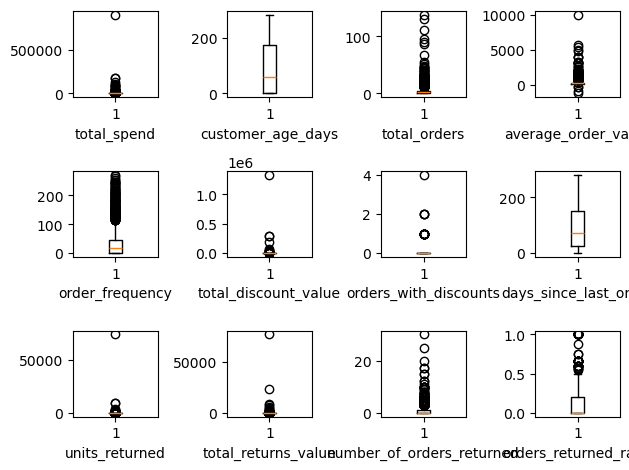

In [50]:
# Investigating & Cleaning Outliers

features = ['total_spend', 'customer_age_days', 'total_orders',
            'average_order_value', 'order_frequency', 'total_discount_value',
            'orders_with_discounts', 'days_since_last_order', 'units_returned',
            'total_returns_value', 'number_of_orders_returned', 'orders_returned_ratio']

df[features] = df[features].fillna(0)


def boxplots(df, features):
    figure, axes = plt.subplots(3, 4)
    axes = axes.flatten()

    i = 0
    for col in features:
        axes[i].boxplot(df[col])
        axes[i].set_xlabel(col)
        i += 1

    plt.tight_layout()
    plt.show()

boxplots(df, features)

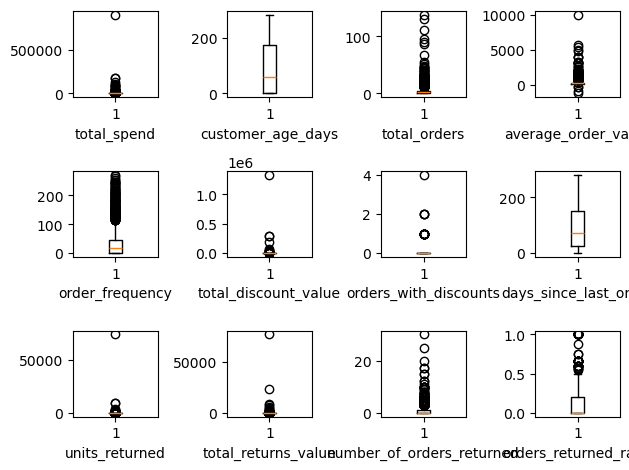

In [51]:
# Remove extreme outliers
df_clean = df[df['total_spend'] < df['total_spend'].quantile(0.99)]
boxplots(df, features)

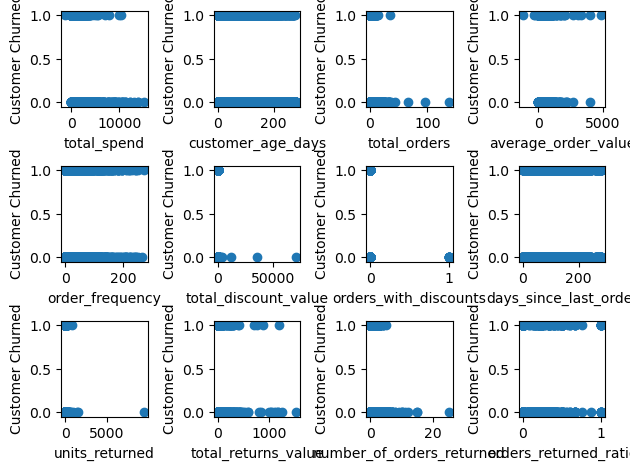

In [52]:
# Split data into train and test
from sklearn.model_selection import train_test_split

# Convert dataframe into Numpy array
X = df_clean[features].to_numpy()
y = df_clean['customer_churned'].to_numpy()

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

m,n = X_train.shape

figure, axes = plt.subplots(3, 4)
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

# Logistic Regression
Running the model

Accuracy: 0.6848958333333334
Actual: [1 1 1 ... 1 0 0]
Predicted: [1 1 1 ... 0 0 0]

total_spend: -0.30404474913784274
customer_age_days: -0.5802108519012356
total_orders: -0.6070091930084577
average_order_value: 0.034635312137347316
order_frequency: 0.20031728979064928
total_discount_value: -0.05028912611663228
orders_with_discounts: -0.2368699304578342
days_since_last_order: 0.25755503684192926
units_returned: -0.2983891716099168
total_returns_value: 0.07321774797537672
number_of_orders_returned: 0.12914626953471864
orders_returned_ratio: -0.05366410978612799


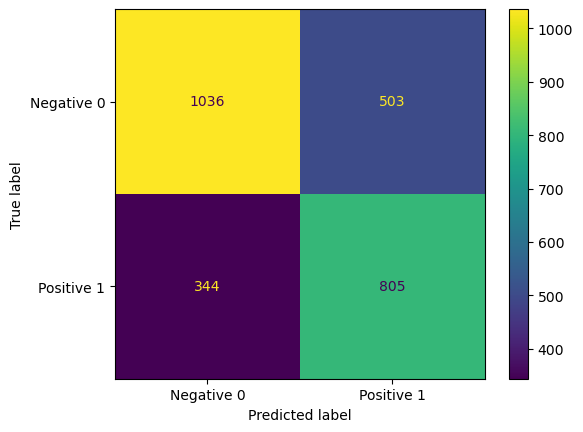

In [53]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

scaler = StandardScaler()

# Scaling input features
X_train_scaled = scaler.fit_transform(X_train)

logr = linear_model.LogisticRegression()

logr.fit(X_train_scaled, y_train)
y_pred = logr.predict(X_train_scaled)

def evaluate(y_train, y_pred):
    print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
    print(f'Actual: {y_train}\nPredicted: {y_pred}\n')

    j = 0
    for col in features:
        print(f'{col}: {logr.coef_[0][j]}')
        j += 1

    matrix = confusion_matrix(y_train, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot()

evaluate(y_train, y_pred)

### Including Polynomial Features

Accuracy: 0.7064732142857143
Actual: [1 1 1 ... 1 0 0]
Predicted: [1 0 1 ... 0 0 0]

total_spend: -0.30404474913784274
customer_age_days: -0.5802108519012356
total_orders: -0.6070091930084577
average_order_value: 0.034635312137347316
order_frequency: 0.20031728979064928
total_discount_value: -0.05028912611663228
orders_with_discounts: -0.2368699304578342
days_since_last_order: 0.25755503684192926
units_returned: -0.2983891716099168
total_returns_value: 0.07321774797537672
number_of_orders_returned: 0.12914626953471864
orders_returned_ratio: -0.05366410978612799


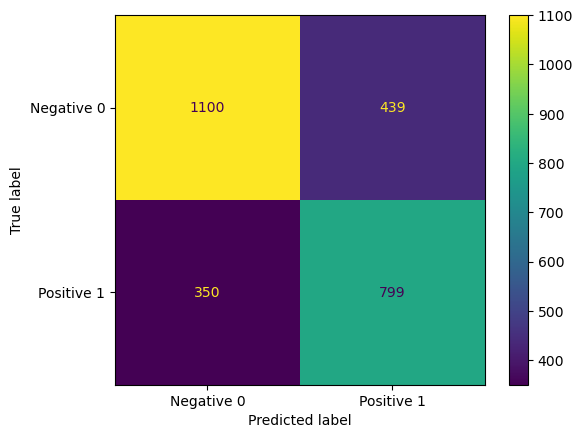

In [54]:
poly = PolynomialFeatures(degree=3)

def transform(X):
    X_poly = poly.fit_transform(X)
    X_poly_scaled = scaler.fit_transform(X_poly)

    return X_poly_scaled

X_train_poly = transform(X_train)

logr_poly = linear_model.LogisticRegression(max_iter=2000)
logr_poly.fit(X_train_poly, y_train)
y_pred_poly = logr_poly.predict(X_train_poly)
y_pred_poly_proba = logr_poly.predict_proba(X_train_poly)[:, 1]

evaluate(y_train, y_pred_poly)

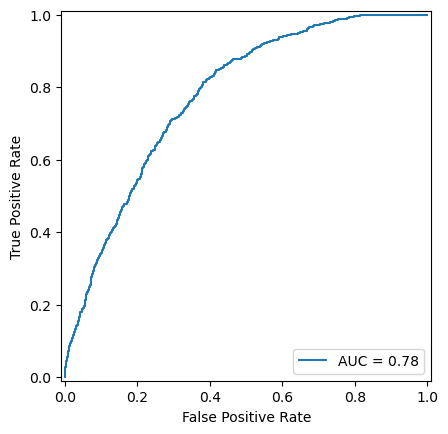

In [55]:
fpr, tpr, thresholds = roc_curve(y_train, y_pred_poly_proba)
roc_auc = auc(fpr, tpr)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()

Accuracy: 0.6651785714285714
Actual: [0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0
 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0
 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 0 0
 1 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0
 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1
 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 1 0
 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 1 1
 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 1
 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 

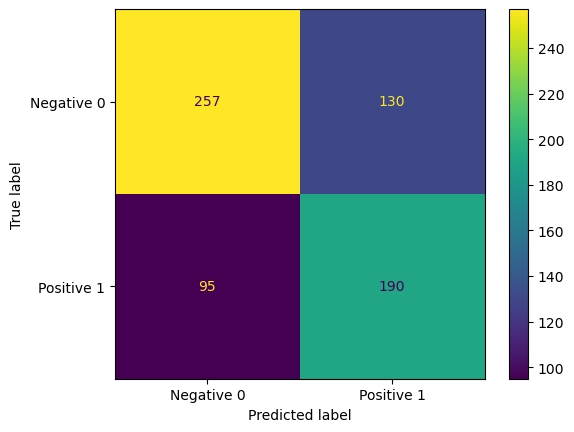

In [56]:
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = logr_poly.predict(X_test_poly)

evaluate(y_test, y_pred_poly)

# Outputting model results

In [57]:
X = df[features].to_numpy()
X_transform = transform(X)
y_pred = logr_poly.predict_proba(X_transform)[:, 1]

df['churn_probability'] = y_pred.ravel()

df.to_csv('Customer Churn Predictions.csv', index=False)